<a href="https://colab.research.google.com/github/aalitorres/Practica-4/blob/main/Pr%C3%A1ctica_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Práctica 4 - Procesamiento geométrico y procesamiento de histograma**

**Objetivo**

Realizar modificaciones a imágenes en el dominio del espacio, específicamente con dos tipos de procesamiento: geométrico y de histograma.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Función para mostrar imágenes en escala de grises
def mostrar(img, titulo):
    plt.imshow(img, cmap='gray')
    plt.title(titulo)
    plt.axis('off')

Importación de librerías

En esta práctica se utilizan las librerías OpenCV, NumPy y Matplotlib.

*   OpenCV permite realizar transformaciones sobre imágenes.
*   NumPy se utiliza para trabajar con matrices y definir las transformaciones geométricas.
*   Matplotlib permite visualizar las imágenes y los histogramas.

Carga de la imagen

Se carga una imagen médica en escala de grises utilizando OpenCV. Trabajar en escala de grises facilita el procesamiento, ya que únicamente se analiza la intensidad de cada píxel.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving image1.jpg to image1 (2).jpg


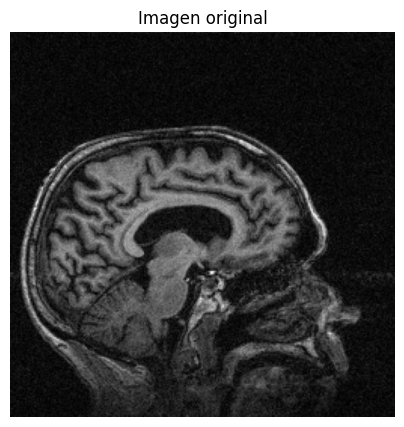

In [ ]:
nombre = list(uploaded.keys())[0]

img = cv2.imread(nombre, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
mostrar(img,"Imagen original")
plt.show()

**PARTE I**

Ejercicio 1 - Traslación

Traslación (50,30)

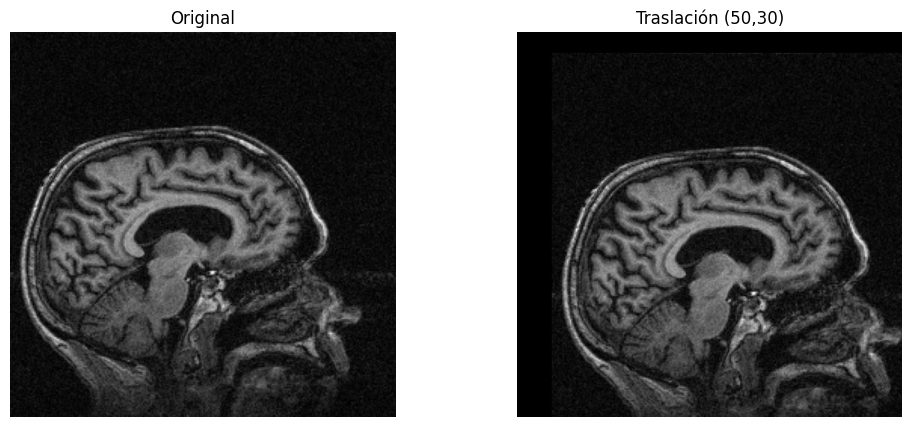

In [ ]:
filas, columnas = img.shape

M = np.float32([[1,0,50],
                [0,1,30]])

trasladada = cv2.warpAffine(img,M,(columnas,filas))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
mostrar(img,"Original")

plt.subplot(1,2,2)
mostrar(trasladada,"Traslación (50,30)")

plt.show()

**Traslación con valores enteros**

La traslación consiste en desplazar todos los píxeles de la imagen una determinada distancia sin modificar su forma. En este ejercicio la imagen se desplazó 50 píxeles en el eje X y 30 píxeles en el eje Y.

**Traslación decimal (20.5,15.5)**

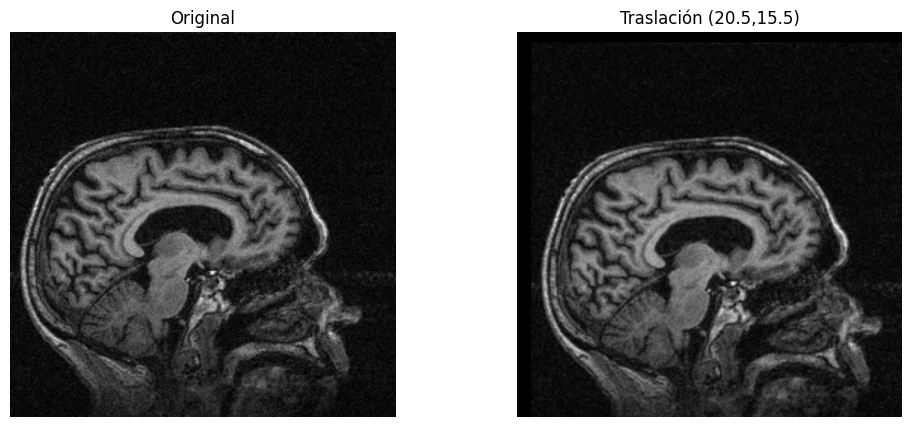

In [ ]:
M_decimal = np.float32([[1,0,20.5],
                        [0,1,15.5]])

trasladada_decimal = cv2.warpAffine(img,M_decimal,(columnas,filas))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
mostrar(img,"Original")

plt.subplot(1,2,2)
mostrar(trasladada_decimal,"Traslación (20.5,15.5)")

plt.show()

En este caso se realizó una traslación utilizando desplazamientos decimales. OpenCV interpola automáticamente los valores de intensidad para generar la nueva posición de los píxeles, produciendo un desplazamiento más preciso.

**Ejercicio 2 - Rotación**

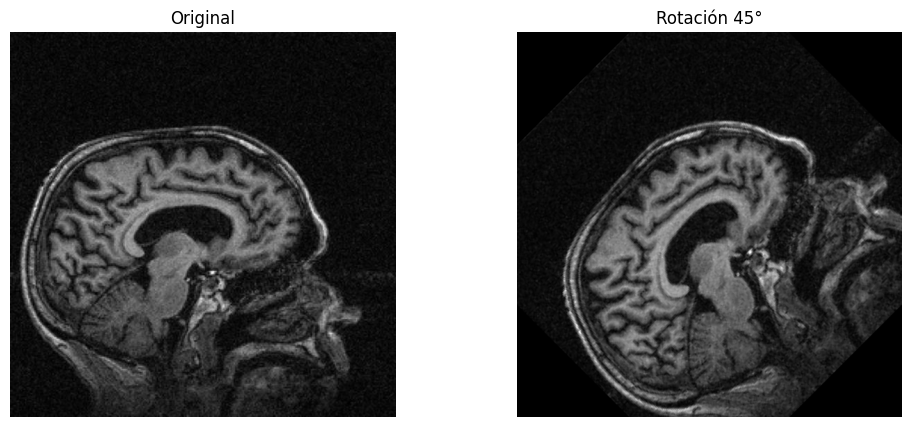

In [ ]:
centro = (columnas//2, filas//2)

M_rot = cv2.getRotationMatrix2D(centro,45,1)

rotada = cv2.warpAffine(img,M_rot,(columnas,filas))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
mostrar(img,"Original")

plt.subplot(1,2,2)
mostrar(rotada,"Rotación 45°")

plt.show()

**Rotación**

La rotación modifica la orientación de la imagen alrededor de un punto de referencia. En este ejercicio se utilizó el centro de la imagen como eje de rotación y se aplicó un ángulo de 45°, manteniendo la misma escala.

**Ejercicio 3 - Escalado**

150%

In [ ]:
escala150 = cv2.resize(img,None,fx=1.5,fy=1.5,interpolation=cv2.INTER_LINEAR)

50%

In [ ]:
escala50 = cv2.resize(img,None,fx=0.5,fy=0.5,interpolation=cv2.INTER_AREA)

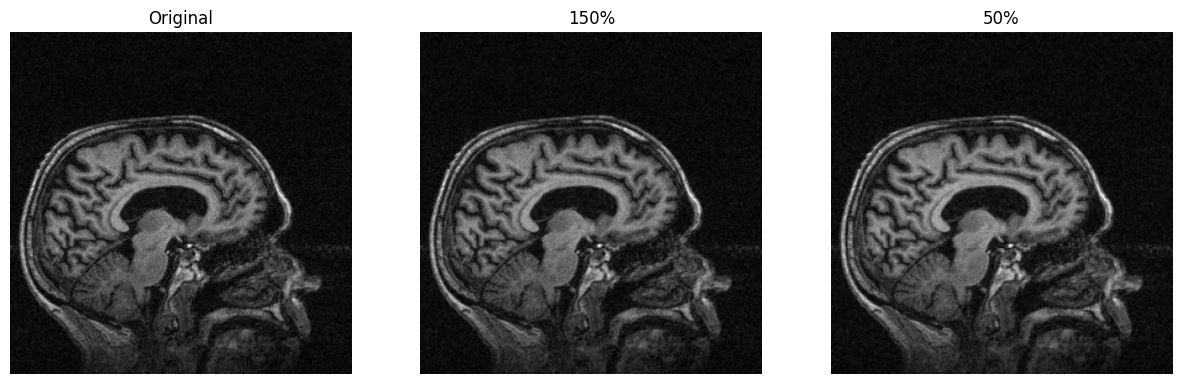

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
mostrar(img,"Original")

plt.subplot(1,3,2)
mostrar(escala150,"150%")

plt.subplot(1,3,3)
mostrar(escala50,"50%")

plt.show()

El escalado modifica el tamaño de la imagen conservando su contenido. Se realizó una ampliación del 150% y una reducción al 50%, empleando diferentes métodos de interpolación para mantener la calidad de la imagen.

**Parte II.- Ecualización de histograma**

Ejercicio 1: Ecualización.

In [ ]:
uploaded = files.upload()

Saving COVID19(107).jpg to COVID19(107).jpg


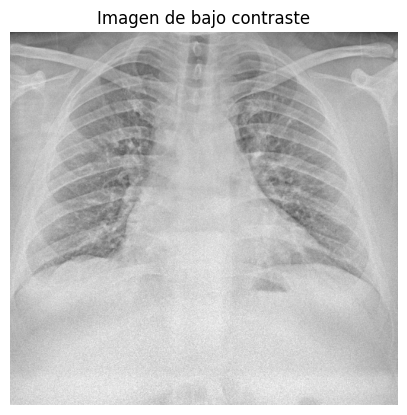

In [ ]:
nombre2 = list(uploaded.keys())[0]

img2 = cv2.imread(nombre2,cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
mostrar(img2,"Imagen de bajo contraste")
plt.show()

Se cargó una segunda imagen médica caracterizada por presentar un contraste reducido, condición que dificulta la identificación de estructuras anatómicas.

**Histograma original**

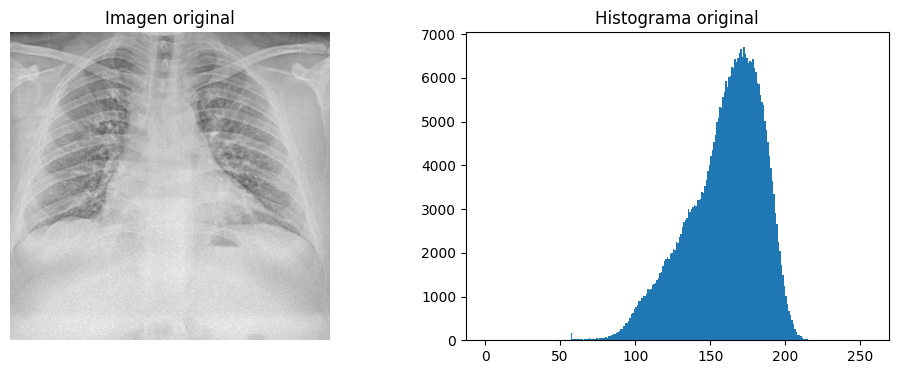

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
mostrar(img2,"Imagen original")

plt.subplot(1,2,2)
plt.hist(img2.ravel(), bins=256, range=(0, 256))
plt.title("Histograma original")
plt.title("Histograma original")

plt.show()

El histograma representa la distribución de los niveles de intensidad presentes en la imagen. En imágenes de bajo contraste es común observar una concentración de píxeles dentro de un rango reducido de intensidades.

Ecualización

In [ ]:
ecualizada = cv2.equalizeHist(img2)

Comparación

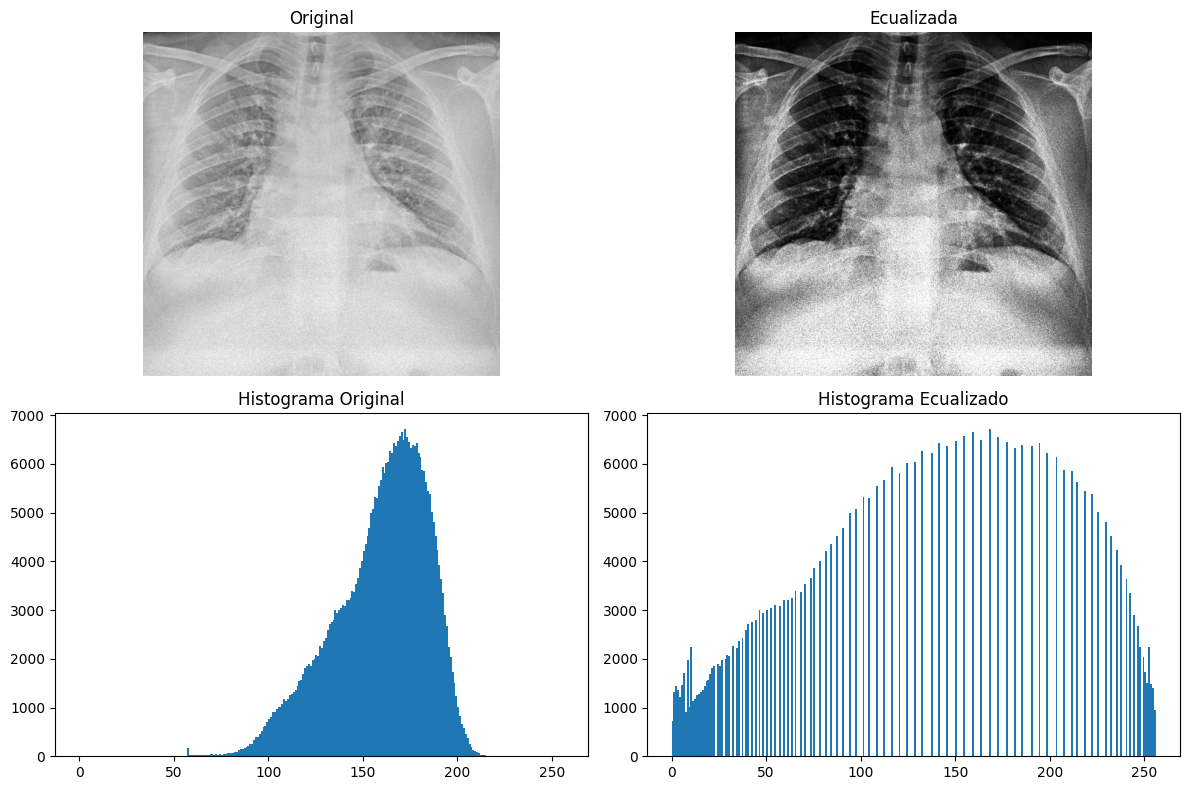

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
mostrar(img2,"Original")

plt.subplot(2,2,2)
mostrar(ecualizada,"Ecualizada")

plt.subplot(2,2,3)
plt.hist(img2.ravel(), bins=256, range=(0,256))
plt.title("Histograma Original")

plt.subplot(2,2,4)
plt.hist(ecualizada.ravel(), bins=256, range=(0,256))
plt.title("Histograma Ecualizado")

plt.tight_layout()
plt.show()

Ecualización del histograma

La ecualización redistribuye los niveles de intensidad de la imagen para incrementar el contraste global. Como resultado, las estructuras anatómicas se distinguen con mayor claridad y el histograma presenta una distribución más uniforme.

Conclusión

Durante esta práctica se aplicaron diferentes técnicas de procesamiento de imágenes en el dominio espacial. En la primera parte se realizaron transformaciones geométricas como traslación, rotación y escalado, observando cómo estas modifican la posición, orientación y tamaño de la imagen sin alterar su información esencial. En la segunda parte se aplicó la ecualización del histograma para mejorar el contraste de una imagen médica, permitiendo una mejor visualización de las estructuras presentes. Estas técnicas constituyen herramientas fundamentales dentro del procesamiento digital de imágenes, especialmente en aplicaciones médicas donde una adecuada visualización facilita el análisis e interpretación de la información.